preprocessing our data

In [94]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install pyarrow 
%pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

1 EDA

1.1 read the data

In [96]:
df = pd.read_parquet('final.parquet')
df.head()

,index_x,time,pm10,pm2_5,us_aqi,us_aqi_pm2_5,us_aqi_pm10,nitrogen_dioxide,us_aqi_nitrogen_dioxide,latitude,...,city,country,index_y,temperature_2m,wind_speed_10m,relative_humidity_2m,latitudereal,longitudereal,index,carbon_monoxide
0,0,2020-01-01T00:00,9.6,3.5,27.0,24.0,11.0,5.7,3,36.9,...,Annaba,Algeria,0,7.2,8.2,90,36.801403,7.805519,0,165.0
1,1,2020-01-01T01:00,9.4,3.5,NaN,NaN,NaN,5.2,3,36.9,...,Annaba,Algeria,1,6.3,8.4,91,36.801403,7.805519,1,167.0
2,2,2020-01-01T02:00,8.1,3.5,NaN,NaN,NaN,4.4,2,36.9,...,Annaba,Algeria,2,6.2,10.3,90,36.801403,7.805519,2,171.0
3,3,2020-01-01T03:00,7.9,3.9,NaN,NaN,NaN,4.9,2,36.9,...,Annaba,Algeria,3,6.6,9.4,88,36.801403,7.805519,3,171.0
4,4,2020-01-01T04:00,8.3,4.1,NaN,NaN,NaN,8.6,4,36.9,...,Annaba,Algeria,4,6.7,9.2,88,36.801403,7.805519,4,172.0


In [97]:
df.drop(columns=['index_x', 'index_y', 'index'], inplace=True) # no need for these index columns
df.shape

(1273680, 18)

1.2 what are we dealing with

In [98]:
df.shape          


(1273680, 18)

In [99]:
df.info()         


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273680 entries, 0 to 1273679
Data columns (total 18 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   time                     1273680 non-null  object 
 1   pm10                     1273680 non-null  float64
 2   pm2_5                    1273680 non-null  float64
 3   us_aqi                   1270345 non-null  float64
 4   us_aqi_pm2_5             1270345 non-null  float64
 5   us_aqi_pm10              1270345 non-null  float64
 6   nitrogen_dioxide         1273680 non-null  float64
 7   us_aqi_nitrogen_dioxide  1273680 non-null  int64  
 8   latitude                 1273680 non-null  float64
 9   longitude                1273680 non-null  float64
 10  city                     1273680 non-null  object 
 11  country                  1273680 non-null  object 
 12  temperature_2m           1273680 non-null  float64
 13  wind_speed_10m           1273680 non-null 

In [100]:
df.describe() 

,pm10,pm2_5,us_aqi,us_aqi_pm2_5,us_aqi_pm10,nitrogen_dioxide,us_aqi_nitrogen_dioxide,latitude,longitude,temperature_2m,wind_speed_10m,relative_humidity_2m,latitudereal,longitudereal,carbon_monoxide
count,1.273680e+06,1.273680e+06,1.270345e+06,1.270345e+06,1.270345e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06,1.273680e+06
mean,1.853330e+01,1.247913e+01,4.792895e+01,4.504429e+01,1.673276e+01,1.059738e+01,5.220627e+00,4.535655e+01,1.439655e+01,1.367604e+01,1.161821e+01,7.141199e+01,4.535652e+01,1.439734e+01,1.776516e+02
std,1.337989e+01,9.691577e+00,2.160024e+01,2.384912e+01,1.046391e+01,1.011222e+01,4.995044e+00,7.491900e+00,1.393423e+01,8.394094e+00,7.229103e+00,2.037603e+01,7.489281e+00,1.393777e+01,8.429195e+01
min,5.000000e-01,5.000000e-01,9.000000e+00,3.000000e+00,1.000000e+00,2.000000e-01,0.000000e+00,3.040000e+01,-9.599999e+00,-2.060000e+01,0.000000e+00,5.000000e+00,3.033392e+01,-9.601410e+00,5.900000e+01
25%,9.800000e+00,5.900000e+00,3.200000e+01,2.600000e+01,9.000000e+00,4.200000e+00,2.000000e+00,3.950000e+01,4.400000e+00,7.400000e+00,6.200000e+00,5.800000e+01,3.947276e+01,4.370504e+00,1.330000e+02
50%,1.500000e+01,9.800000e+00,4.400000e+01,4.200000e+01,1.400000e+01,7.600000e+00,4.000000e+00,4.480000e+01,1.250000e+01,1.320000e+01,1.000000e+01,7.600000e+01,4.481546e+01,1.253012e+01,1.590000e+02
75%,2.330000e+01,1.610000e+01,5.900000e+01,5.800000e+01,2.100000e+01,1.350000e+01,7.000000e+00,5.150000e+01,2.330000e+01,1.940000e+01,1.560000e+01,8.800000e+01,5.149385e+01,2.326440e+01,1.990000e+02
max,3.395000e+02,1.563000e+02,1.850000e+02,1.790000e+02,1.320000e+02,2.098000e+02,1.020000e+02,6.220000e+01,4.480000e+01,5.130000e+01,6.960000e+01,1.000000e+02,6.224956e+01,4.481781e+01,4.184000e+03


1.3 missing values in each column 


In [101]:
df.isnull().sum()

time                          0
pm10                          0
pm2_5                         0
us_aqi                     3335
us_aqi_pm2_5               3335
us_aqi_pm10                3335
nitrogen_dioxide              0
us_aqi_nitrogen_dioxide       0
latitude                      0
longitude                     0
city                          0
country                       0
temperature_2m                0
wind_speed_10m                0
relative_humidity_2m          0
latitudereal                  0
longitudereal                 0
carbon_monoxide               0
dtype: int64

1.4 check duplicate Rows

In [102]:
df.duplicated().sum()

np.int64(0)

1.5 understand the columns

In [103]:
df.columns.tolist()  # List of column names

['time',
 'pm10',
 'pm2_5',
 'us_aqi',
 'us_aqi_pm2_5',
 'us_aqi_pm10',
 'nitrogen_dioxide',
 'us_aqi_nitrogen_dioxide',
 'latitude',
 'longitude',
 'city',
 'country',
 'temperature_2m',
 'wind_speed_10m',
 'relative_humidity_2m',
 'latitudereal',
 'longitudereal',
 'carbon_monoxide']

In [104]:
df['city'].unique() #how many cities are we dealing with?

array(['Annaba', 'Blida', 'Chlef', 'Yerevan', 'Linz', 'Minsk', 'Grodno',
       'Vitebsk', 'Liège', 'Antwerp', 'Sarajevo', 'Tuzla', 'Banja Luka',
       'Sofia', 'Burgas', 'London', 'Manchester', 'Zagreb', 'Brno',
       'Ostrava', 'Vejle', 'Herning', 'Randers', 'Kolding', 'Odense',
       'Aalborg', 'Aarhus', 'Horsens', 'Hørsholm', 'Hjørring', 'Slagelse',
       'Al Mansurah', 'Tanta', 'Gondar', 'Jyväskylä', 'Tampere',
       'Besançon', 'Nantes', 'Le Mans', 'Tours', 'Angers', 'Marseille',
       'Metz', 'Toulon', 'Strasbourg', 'Reims', 'Lille', 'Bordeaux',
       'Toulouse', 'Hamburg', 'Bremen', 'Karlsruhe', 'Halle', 'Magdeburg',
       'Thessaloniki', 'Sopron', 'Miskolc', 'Salmās', 'Amara',
       'Dīwānīyah', 'Baghdad', 'Dublin', 'Palermo', 'Bologna', 'Parma',
       'Messina', 'Modena', 'Verona', 'Marsala', 'Venezia', 'Irbid',
       'Riga', 'Vilnius', 'Valletta', 'Sefrou', 'Meknes', 'Fes', 'Rabat',
       'Sidi Slimane', 'Marrakesh', 'Agadir', 'Oujda', 'Tétouan',
       'Rotterda

In [105]:
df['country'].unique() #how many countries are we dealing with?

array(['Algeria', 'Armenia', 'Austria', 'Belarus', 'Belgium',
       'Bosnia and Herzegovina', 'Bulgaria', 'United Kingdom', 'Croatia',
       'Czechia', 'Denmark', 'Egypt', 'Spain', 'Finland', 'France',
       'Germany', 'Greece', 'Hungary', 'Iran', 'Romania', 'Iraq',
       'Ireland', 'Italy', 'Jordan', 'Latvia', 'Lithuania', 'Malta',
       'Morocco', 'The Netherlands', 'Poland', 'Portugal', 'Moldova',
       'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Sweden',
       'Switzerland', 'Syria', 'Tunisia', 'Türkiye'], dtype=object)

In [106]:
df['time'].min(), df['time'].max() #what is the time range of our data?

('2020-01-01T00:00', '2020-12-31T23:00')

1.6 visualization

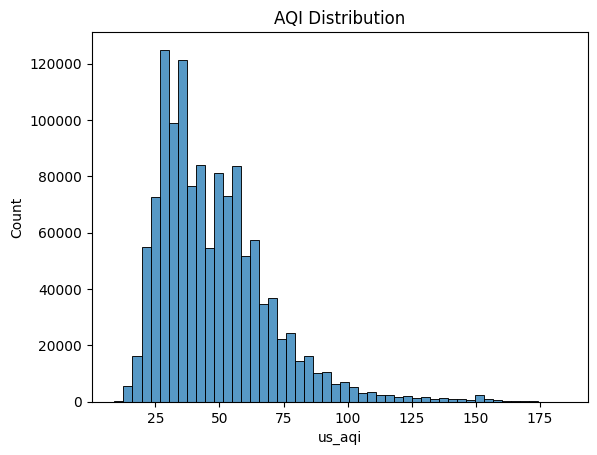

In [107]:
sns.histplot(df['us_aqi'].dropna(), bins=50)
plt.title('AQI Distribution')
plt.show()

0–50 → Good



51–100 → Moderate


101–150 → Unhealthy for sensitive groups



151–200 → Unhealthy

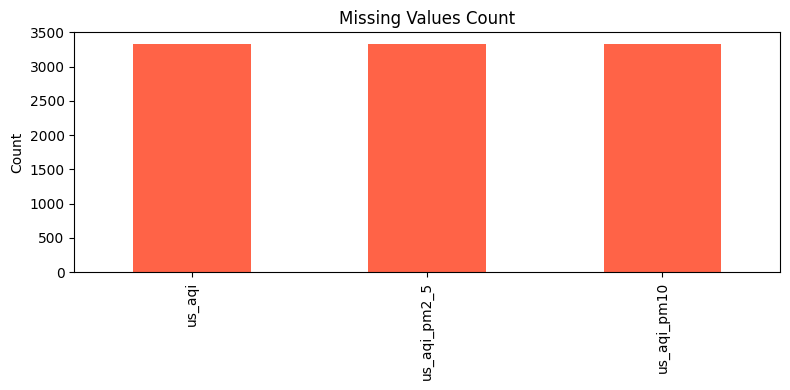

In [108]:
missing = df.isnull().sum()
missing = missing[missing > 0] 

missing.plot(kind='bar', color='tomato', figsize=(8, 4))
plt.title('Missing Values Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

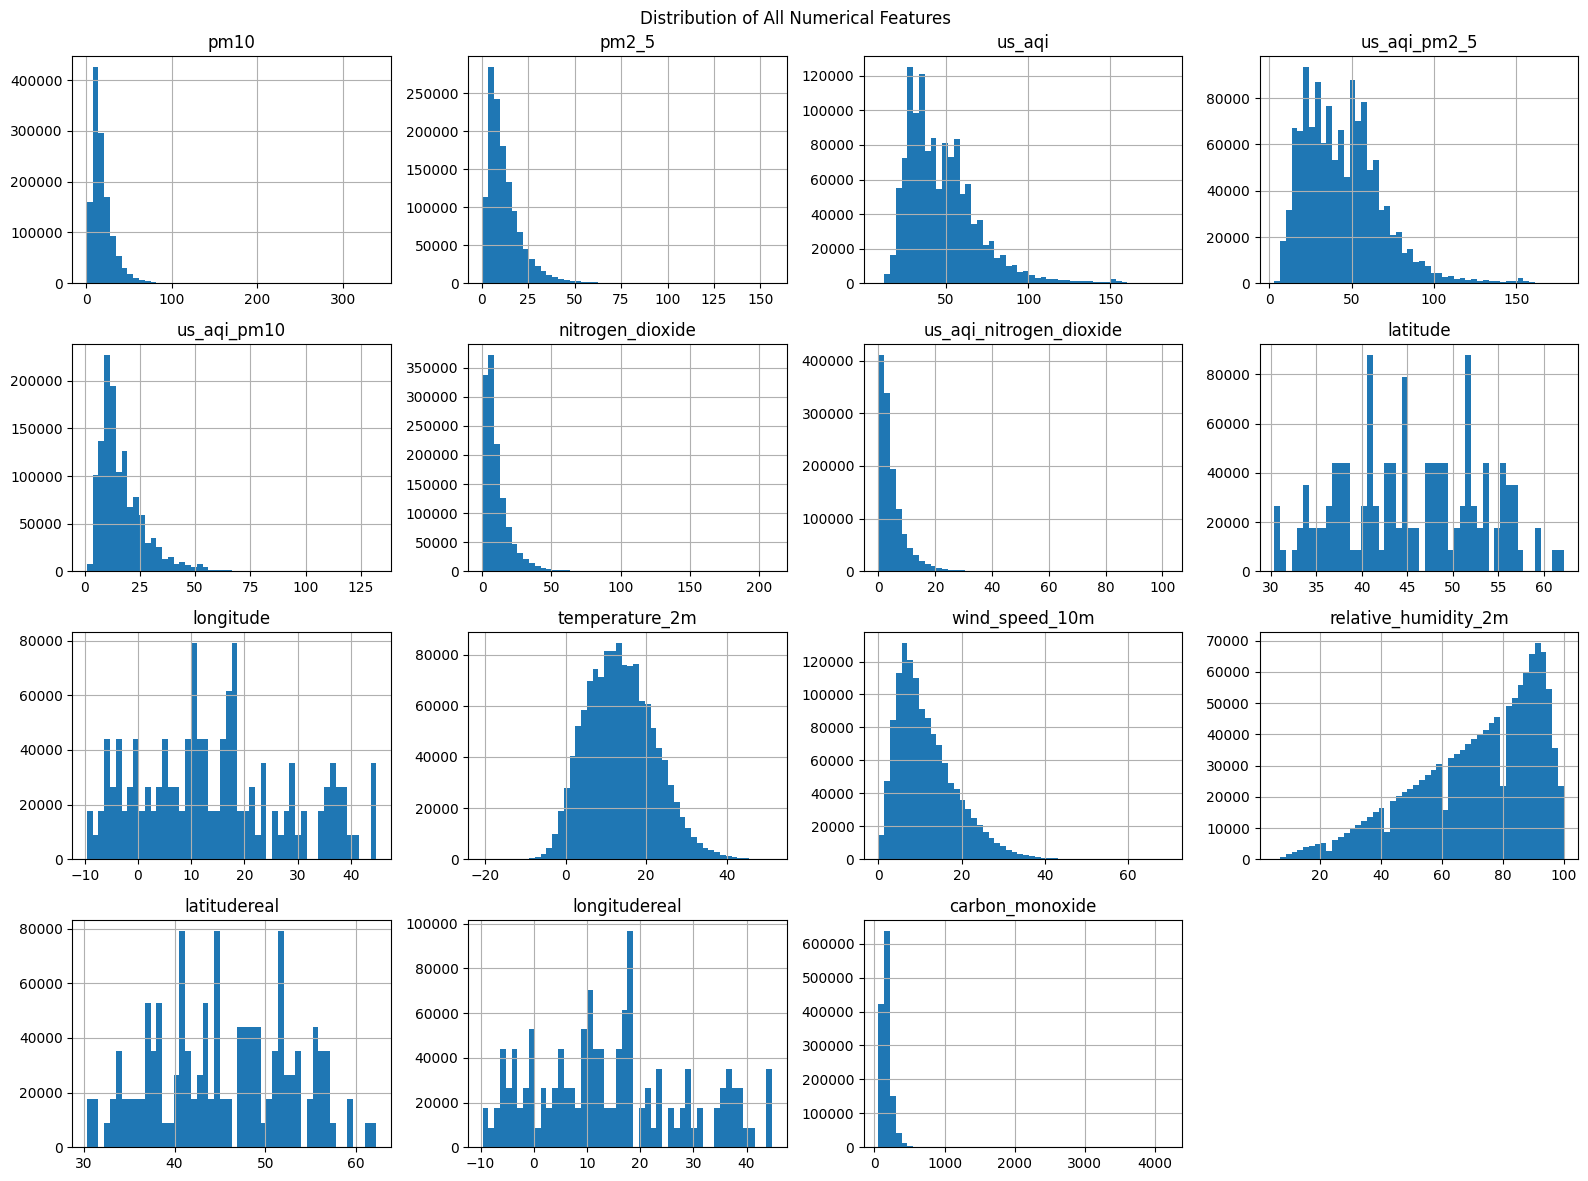

In [109]:
df.select_dtypes(include='number').hist(figsize=(16, 12), bins=50)
plt.suptitle('Distribution of All Numerical Features')
plt.tight_layout()
plt.show()

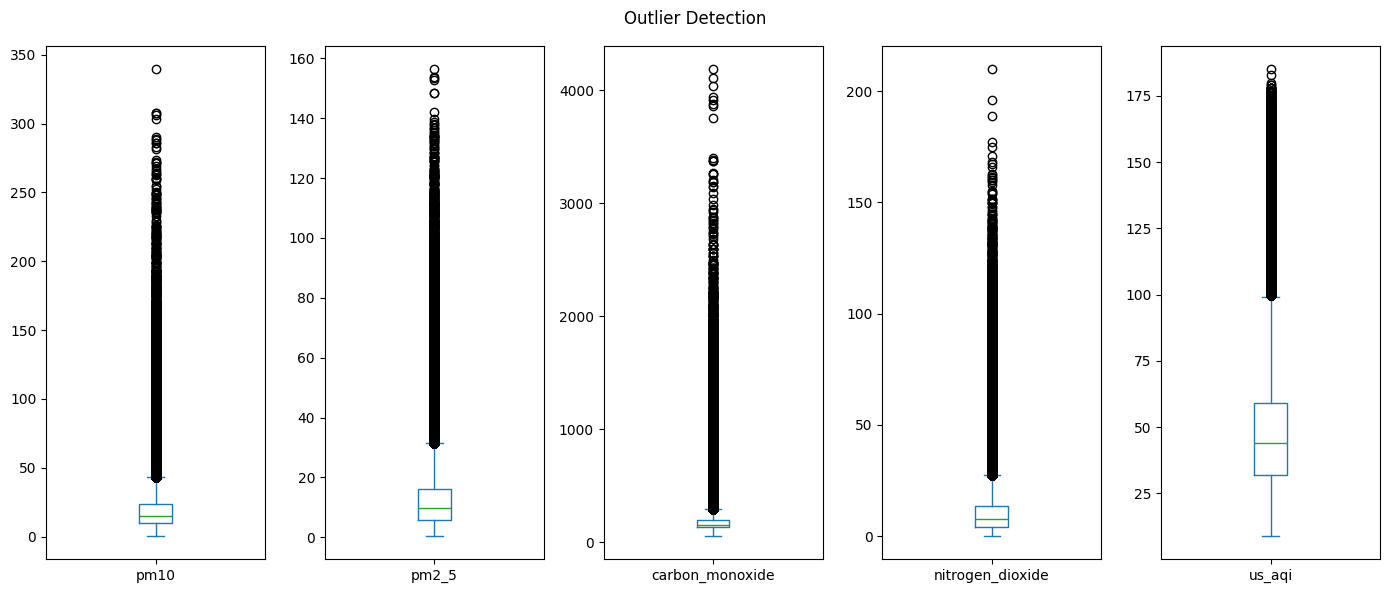

In [110]:
cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'us_aqi']
df[cols].plot(kind='box', figsize=(14, 6), subplots=True, layout=(1,5))
plt.suptitle('Outlier Detection')
plt.tight_layout()
plt.show()

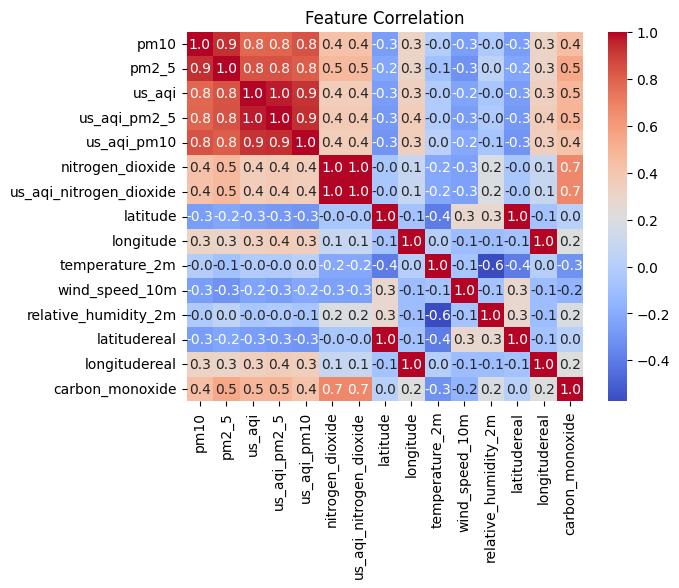

In [111]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

2 Preprocessing Data

2.1 Dropping Drop Redundant Columns 

In [112]:
df.drop(columns=[
    'us_aqi_pm2_5',        # same as us_aqi
    'us_aqi_pm10',         # same as us_aqi
    'us_aqi_nitrogen_dioxide',  # same as nitrogen_dioxide
    'latitudereal',        # same as latitude
    'longitudereal',       # same as longitude
], inplace=True)

In [113]:
print(df.shape)
print(df.columns.tolist())

(1273680, 13)
['time', 'pm10', 'pm2_5', 'us_aqi', 'nitrogen_dioxide', 'latitude', 'longitude', 'city', 'country', 'temperature_2m', 'wind_speed_10m', 'relative_humidity_2m', 'carbon_monoxide']


2.2 Handling missing values

In [114]:
df['us_aqi'].fillna(df['us_aqi'].median(), inplace=True)

In [115]:
df.isnull().sum()

time                    0
pm10                    0
pm2_5                   0
us_aqi                  0
nitrogen_dioxide        0
latitude                0
longitude               0
city                    0
country                 0
temperature_2m          0
wind_speed_10m          0
relative_humidity_2m    0
carbon_monoxide         0
dtype: int64

2.3 Convert time column (string) into (numerical)

In [116]:
df['time'] = pd.to_datetime(df['time'])     #the time part in the time column
df['hour'] = df['time'].dt.hour             #the hours part in the time column
df['month'] = df['time'].dt.month           #the month part in the time column
df['day_of_week'] = df['time'].dt.dayofweek #the day of the week part in the time column
df.drop(columns=['time'], inplace=True)     # then drop original time column

2.4 Handling outliers

In [117]:
for col in ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

2.5 Encode Categorical Columns

In [118]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['city'] = le.fit_transform(df['city'])
df['country'] = le.fit_transform(df['country'])

2.6 Scale Numerical Features

In [119]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols.remove('us_aqi')  # don't scale the target variable
df[num_cols] = scaler.fit_transform(df[num_cols])

2.7 Split the Data

. *so the model learns on one part and gets tested on a part it has never seen*

In [120]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['us_aqi'])
y = df['us_aqi']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [121]:
print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (1018944, 14)
Test: (254736, 14)


"FINAL CHECK"

In [122]:
print('Final shape:', df.shape)


Final shape: (1273680, 15)


In [123]:
print('Any nulls left:', df.isnull().sum().sum())


Any nulls left: 0


In [124]:

print('Data types:\n', df.dtypes)

Data types:
 pm10                    float64
pm2_5                   float64
us_aqi                  float64
nitrogen_dioxide        float64
latitude                float64
longitude               float64
city                    float64
country                 float64
temperature_2m          float64
wind_speed_10m          float64
relative_humidity_2m    float64
carbon_monoxide         float64
hour                    float64
month                   float64
day_of_week             float64
dtype: object
